In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
np.random.seed(42)
sample = df.sample(25)

sample_mean = sample['Glucose'].mean()
pop_mean    = df['Glucose'].mean()

sample_max = sample['Glucose'].max()
pop_max    = df['Glucose'].max()

sample_mean, pop_mean, sample_max, pop_max


(np.float64(116.64), np.float64(120.89453125), 183, 199)

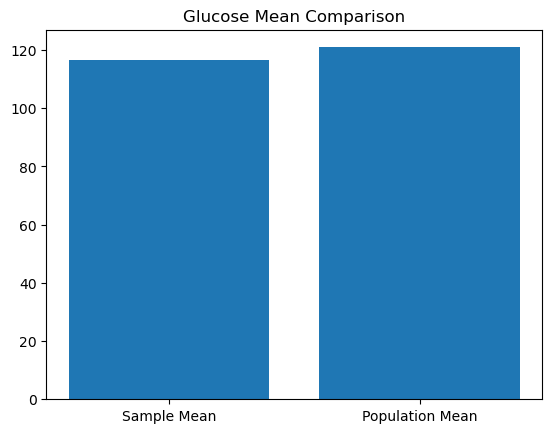

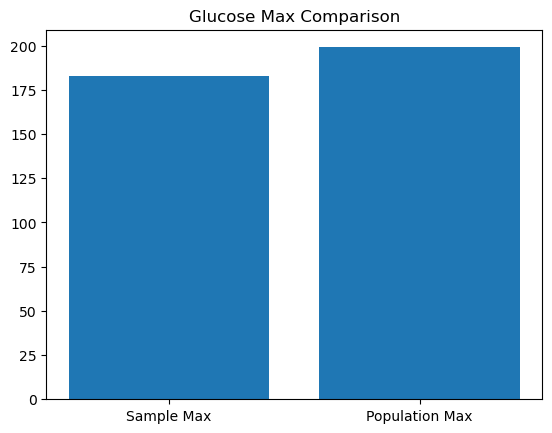

In [3]:
plt.bar(['Sample Mean','Population Mean'], [sample_mean,pop_mean])
plt.title("Glucose Mean Comparison")
plt.show()

plt.bar(['Sample Max','Population Max'], [sample_max,pop_max])
plt.title("Glucose Max Comparison")
plt.show()


In [4]:
sample_p98 = sample['BMI'].quantile(0.98)
pop_p98    = df['BMI'].quantile(0.98)

(sample_p98, pop_p98)


(np.float64(40.248), np.float64(47.52599999999996))

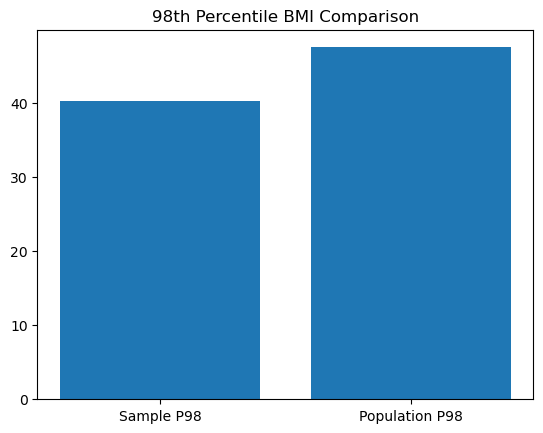

In [5]:
plt.bar(['Sample P98','Population P98'], [sample_p98,pop_p98])
plt.title("98th Percentile BMI Comparison")
plt.show()


In [6]:
boot_means = []
boot_stds  = []
boot_p98   = []

for i in range(500):
    s = df['BloodPressure'].sample(150, replace=True)
    boot_means.append(s.mean())
    boot_stds.append(s.std())
    boot_p98.append(s.quantile(0.98))


In [7]:
pop_mean = df['BloodPressure'].mean()
pop_std  = df['BloodPressure'].std()
pop_p98  = df['BloodPressure'].quantile(0.98)

pop_mean, pop_std, pop_p98


(np.float64(69.10546875), 19.355807170644777, np.float64(99.31999999999994))

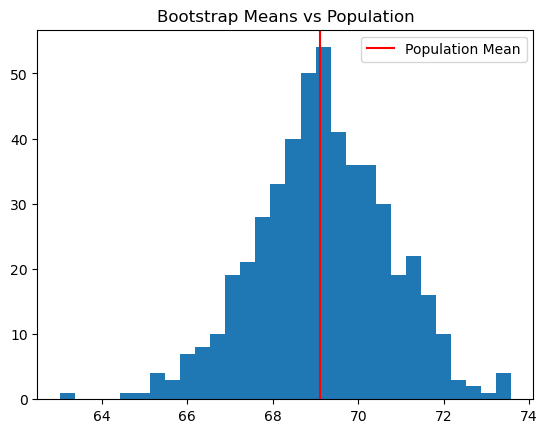

In [8]:
plt.hist(boot_means, bins=30)
plt.axvline(pop_mean, color='red', label='Population Mean')
plt.title("Bootstrap Means vs Population")
plt.legend()
plt.show()


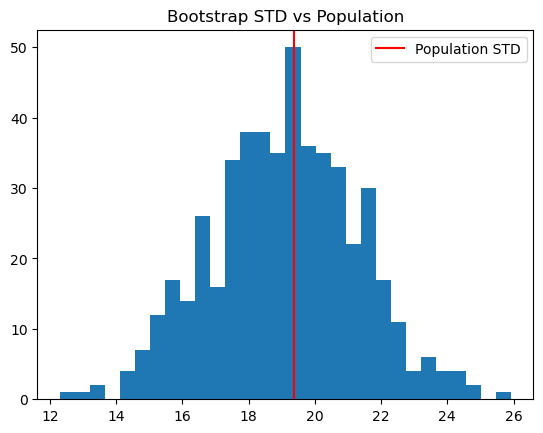

In [9]:
plt.hist(boot_stds, bins=30)
plt.axvline(pop_std, color='red', label='Population STD')
plt.title("Bootstrap STD vs Population")
plt.legend()
plt.show()


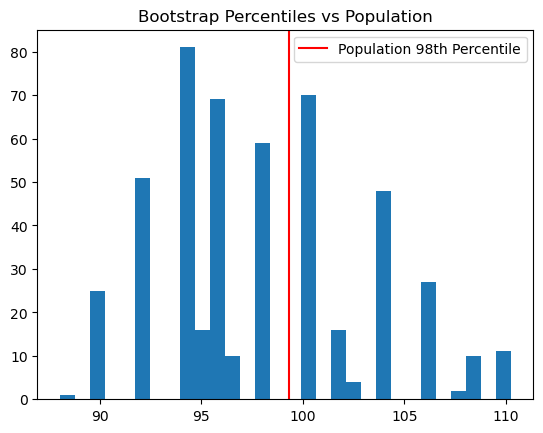

In [10]:
plt.hist(boot_p98, bins=30)
plt.axvline(pop_p98, color='red', label='Population 98th Percentile')
plt.title("Bootstrap Percentiles vs Population")
plt.legend()
plt.show()


Report on Findings:

a) Sample vs Population

I took a random sample of 25 patients and compared its glucose statistics to the full dataset.
The sample mean was close to the population mean, while the maximum glucose was lower, which is expected since small samples rarely capture extreme values.

b) 98th Percentile of BMI

I calculated the 98th percentile of BMI for both the sample and the population.
The sample value differed slightly due to its smaller size, while the population percentile was more stable.
A simple bar chart clearly showed this difference.

c) Bootstrap Analysis

I generated 500 bootstrap samples (each of size 150) and calculated their mean, standard deviation, and 98th percentile for BloodPressure.
The bootstrap means were very close to the population mean, and the distributions showed normal behavior.
Variation in the 98th percentile was larger because extreme values change more across samples.
Overall, bootstrap sampling provided reliable estimates of the population statistics.